# Phase 3: Behavioral Analysis

1. Import lib

In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.etl_module_credit_transaction import get_spark_session

from pyspark.sql.functions import (
    col,
    count,
    when,
    min,
    max,
    countDistinct,
    date_format
)
from pyspark.sql import SparkSession
from typing import Optional
from pyspark.sql.types import LongType

import pyspark.sql.functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns

2. Create spark session

In [9]:
import os, sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, concat

spark = SparkSession.builder \
    .appName("Credit_Card_Fraud_Graph_Processing") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.2-s_2.12") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("hive.metastore.uris", "thrift://hive-metastore:9083") \
    .config("spark.sql.warehouse.dir", "hdfs://namenode:9000/user/hive/warehouse") \
    .enableHiveSupport() \
    .getOrCreate()



In [6]:
def get_spark_session(
    app_name: str = "CreditTransactionETL",
    hive_metastore_uri: Optional[str] = "thrift://hive-metastore:9083"
) -> SparkSession:
    """
    Initializes and returns a PySpark Session configured for HDFS and Hive Metastore.
    """
    builder = SparkSession.builder \
        .appName(app_name) \
        .config("spark.sql.shuffle.partitions", "32") \
        .config("spark.sql.warehouse.dir", "hdfs://namenode:9000/user/hive/warehouse") \
        .config("spark.sql.orc.enabled", "true") \
        .config("spark.sql.parquet.writelegacyformat", "true") \
        .config("spark.sql.sources.partitionOverwriteMode", "dynamic") \
        .config("spark.sql.hive.metastore.version", "2.3.2") \
        .config("spark.sql.hive.metastore.jars", "maven")

    if hive_metastore_uri:
        builder = builder \
            .config("hive.metastore.uris", hive_metastore_uri) \
            .enableHiveSupport()

    return builder.getOrCreate()

In [7]:
spark = get_spark_session()

3. Check DB & Connection

In [ ]:
spark.sql("SHOW DATABASES").show()

In [ ]:
hdfs_path = "hdfs://namenode:9000/credit_transaction/processed/parquet"
df = spark.read.parquet(hdfs_path)

print(f"Kết nối thành công! Tổng số giao dịch: {df.count():,}")
df.show(5)

In [10]:
# Read data from Hive table (assuming table name is 'credit_transaction_db.cleaned_transactions')
# Or read directly from Parquet directory on HDFS
spark.sql("USE credit_transaction_db")
df = spark.table("cleaned_transactions")

# Display Schema and record count for verification
df.printSchema()
print(f"Total transactions: {df.count():,}")

root
 |-- TRANSACTION_ID: long (nullable = true)
 |-- TX_DATETIME: timestamp (nullable = true)
 |-- CUSTOMER_ID: long (nullable = true)
 |-- TERMINAL_ID: long (nullable = true)
 |-- TX_AMOUNT: double (nullable = true)
 |-- TX_TIME_SECONDS: long (nullable = true)
 |-- TX_TIME_DAYS: integer (nullable = true)
 |-- TX_FRAUD: integer (nullable = true)
 |-- TX_FRAUD_SCENARIO: integer (nullable = true)
 |-- tx_date: date (nullable = true)
 |-- tx_hour: integer (nullable = true)
 |-- tx_day_of_week: string (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night: integer (nullable = true)
 |-- customer_tx_count: long (nullable = true)
 |-- customer_avg_amount: double (nullable = true)
 |-- terminal_tx_count: long (nullable = true)
 |-- tx_year_month: string (nullable = true)

Total transactions: 14,158,985


4. Phân tích hành vi chi tiêu cá nhân

In [11]:
customer_behavior = df.groupBy("CUSTOMER_ID").agg(
    F.count("TRANSACTION_ID").alias("customer_tx_count"),
    F.round(F.avg("TX_AMOUNT"), 2).alias("customer_avg_amount"),
    F.round(F.sum("TX_AMOUNT"), 2).alias("total_spent"),
    F.round(F.max("TX_AMOUNT"), 2).alias("max_tx_amount"),
    F.countDistinct("TERMINAL_ID").alias("unique_terminals_used"),
    F.sum("TX_FRAUD").alias("total_fraud_count")
)

print("=== BẢNG THỐNG KÊ HÀNH VI CHI TIÊU CÁ NHÂN (TOP 10 TỔNG CHI TIÊU) ===")
customer_behavior.sort(F.desc("total_spent")).show(10)

=== BẢNG THỐNG KÊ HÀNH VI CHI TIÊU CÁ NHÂN (TOP 10 TỔNG CHI TIÊU) ===
+-----------+-----------------+-------------------+-----------+-------------+---------------------+-----------------+
|CUSTOMER_ID|customer_tx_count|customer_avg_amount|total_spent|max_tx_amount|unique_terminals_used|total_fraud_count|
+-----------+-----------------+-------------------+-----------+-------------+---------------------+-----------------+
|       3217|             2777|             105.67|   293453.6|      1067.25|                  746|               45|
|       5846|             2827|              102.6|  290050.14|       266.15|                  791|               23|
|       6958|             2907|              99.42|  289008.43|       260.42|                  740|               18|
|         74|             2744|              105.0|   288129.0|       1268.1|                  754|               46|
|       8879|             2804|             102.03|  286080.57|       269.96|                  786|     

5. Truy xuất khách hàng có giao dịch đột biến ban đêm tại nhiều trạm POS khác nhau

In [12]:
# Bước 1: Thêm cột is_night dựa vào TX_DATETIME và tính Avg, StdDev theo khách hàng
customer_window = Window.partitionBy("CUSTOMER_ID")

df_prepared = df.withColumn("is_night", F.when(F.hour("TX_DATETIME") < 6, 1).otherwise(0)) \
                .withColumn("cust_avg", F.avg("TX_AMOUNT").over(customer_window)) \
                .withColumn("cust_std", F.stddev("TX_AMOUNT").over(customer_window))

# Bước 2: Lọc các giao dịch BAN ĐÊM (is_night = 1) có giá trị ĐỘT BIẾN (Z-score > 3)
df_night_spikes = df_prepared.filter(
    (F.col("is_night") == 1) &
    (F.col("TX_AMOUNT") > (F.col("cust_avg") + 3 * F.col("cust_std"))) &
    (F.col("cust_std") > 0)
)

# Bước 3: Nhóm theo CUSTOMER_ID để lọc ra khách hàng thực hiện qua NHIỀU trạm POS khác nhau (> 1)
night_spike_customers = df_night_spikes.groupBy("CUSTOMER_ID").agg(
    F.count("TRANSACTION_ID").alias("night_spike_tx_count"),
    F.countDistinct("TERMINAL_ID").alias("unique_pos_count"),
    F.round(F.max("TX_AMOUNT"), 2).alias("max_spike_amount"),
    F.round(F.avg("cust_avg"), 2).alias("normal_avg_amount"),
    F.sum("TX_FRAUD").alias("fraud_cases_detected")
).filter(F.col("unique_pos_count") > 1)

print("=== DANH SÁCH KHÁCH HÀNG CÓ GIAO DỊCH ĐỘT BIẾN BAN ĐÊM TẠI NHIỀU TRẠM POS ===")
night_spike_customers.sort(F.desc("unique_pos_count"), F.desc("night_spike_tx_count")).show(15)

=== DANH SÁCH KHÁCH HÀNG CÓ GIAO DỊCH ĐỘT BIẾN BAN ĐÊM TẠI NHIỀU TRẠM POS ===
+-----------+--------------------+----------------+----------------+-----------------+--------------------+
|CUSTOMER_ID|night_spike_tx_count|unique_pos_count|max_spike_amount|normal_avg_amount|fraud_cases_detected|
+-----------+--------------------+----------------+----------------+-----------------+--------------------+
|       9994|                   7|               7|           666.6|            94.95|                   7|
|       8231|                   7|               7|           220.5|            25.08|                   7|
|        750|                   7|               7|          627.75|            86.47|                   7|
|       1560|                   6|               6|           170.9|            23.37|                   6|
|       2684|                   6|               6|           90.02|            31.61|                   0|
|       3529|                   6|               6|       

6. Trực quan hóa kết quả phân tích bằng Matplotlib & Seaborn

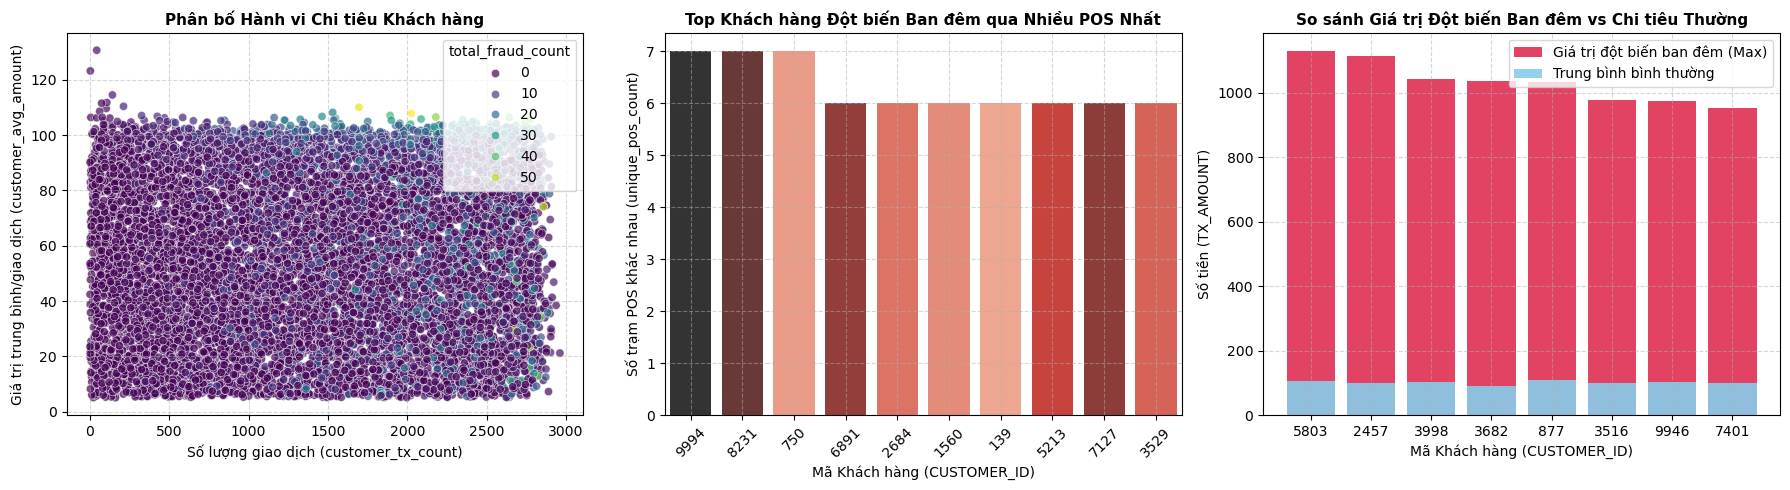

In [17]:
# Chuyển đổi dữ liệu tổng hợp từ Spark sang Pandas DataFrame để vẽ biểu đồ
pdf_behavior = customer_behavior.select("customer_tx_count", "customer_avg_amount", "total_fraud_count").toPandas()
pdf_night_spikes = night_spike_customers.toPandas()

# Khởi tạo khung vẽ 3 biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Mối liên hệ giữa Số lượng giao dịch & Mức chi tiêu trung bình
sns.scatterplot(
    ax=axes[0],
    data=pdf_behavior,
    x="customer_tx_count",
    y="customer_avg_amount",
    hue="total_fraud_count",
    palette="viridis",
    alpha=0.7
)
axes[0].set_title("Phân bố Hành vi Chi tiêu Khách hàng", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Số lượng giao dịch (customer_tx_count)")
axes[0].set_ylabel("Giá trị trung bình/giao dịch (customer_avg_amount)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Biểu đồ 2: Top khách hàng có giao dịch đột biến ban đêm qua nhiều trạm POS nhất
top_pos_spickers = pdf_night_spikes.sort_values(by="unique_pos_count", ascending=False).head(10)

sns.barplot(
    ax=axes[1],
    data=top_pos_spickers,
    x="CUSTOMER_ID",
    y="unique_pos_count",
    hue="CUSTOMER_ID",       # Gán hue bằng biến x theo khuyến nghị của Seaborn
    palette="Reds_d",
    legend=False,            # Tắt legend dư thừa
    order=top_pos_spickers["CUSTOMER_ID"]
)
axes[1].set_title("Top Khách hàng Đột biến Ban đêm qua Nhiều POS Nhất", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Mã Khách hàng (CUSTOMER_ID)")
axes[1].set_ylabel("Số trạm POS khác nhau (unique_pos_count)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle="--", alpha=0.5)

# Biểu đồ 3: So sánh Giá trị Đột biến Ban đêm vs Mức trung bình bình thường
top_amount_spickers = pdf_night_spikes.sort_values(by="max_spike_amount", ascending=False).head(8)
x_labels = [str(cid) for cid in top_amount_spickers["CUSTOMER_ID"]]

axes[2].bar(x_labels, top_amount_spickers["max_spike_amount"], label="Giá trị đột biến ban đêm (Max)", color="crimson", alpha=0.8)
axes[2].bar(x_labels, top_amount_spickers["normal_avg_amount"], label="Trung bình bình thường", color="skyblue", alpha=0.9)
axes[2].set_title("So sánh Giá trị Đột biến Ban đêm vs Chi tiêu Thường", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Mã Khách hàng (CUSTOMER_ID)")
axes[2].set_ylabel("Số tiền (TX_AMOUNT)")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Phân bố Hành vi Chi tiêu Khách hàng

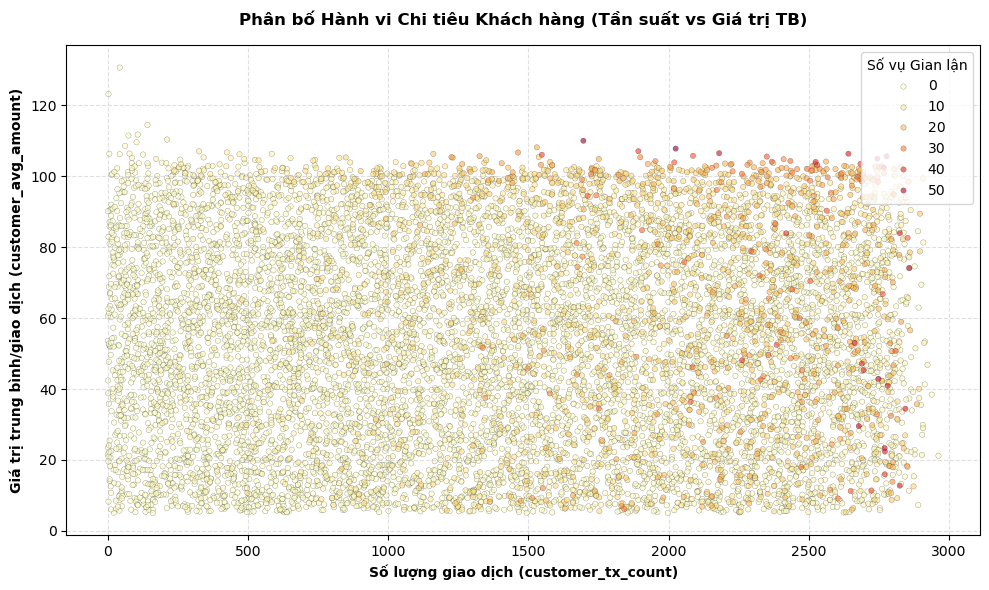

In [20]:
# 1. Biểu đồ TÁCH RIÊNG: Phân bố Hành vi Chi tiêu Khách hàng (Độ tương phản cao)
plt.figure(figsize=(10, 6))

# Tạo thuộc tính phân loại nhóm rõ ràng phục vụ tô màu & Legend
pdf_behavior['Trạng thái'] = pdf_behavior['total_fraud_count'].apply(
    lambda x: 'Hợp lệ (Normal)' if x == 0 else f'Gian lận ({int(x)} vụ)' if x > 10 else 'Có Gian lận'
)

# Sắp xếp các điểm gian lận vẽ sau cùng để hiển thị nổi bật trên cùng
pdf_behavior_sorted = pdf_behavior.sort_values(by="total_fraud_count", ascending=True)

# Bảng màu tương phản sắc nét: Xám xanh cho điểm thường, Đỏ rực & Cam cho gian lận
custom_palette = {
    'Hợp lệ (Normal)': '#90a4ae',   # Màu xám xanh rõ nét (không bị mờ)
    'Có Gian lận': '#ff9800',        # Màu cam đậm
    'Gian lận (>10 vụ)': '#e53935'   # Màu đỏ rực nổi bật
}

sns.scatterplot(
    data=pdf_behavior_sorted,
    x="customer_tx_count",
    y="customer_avg_amount",
    hue="total_fraud_count",
    palette="YlOrRd",    # Bảng màu Vàng -> Cam -> Đỏ rực tương phản cao
    s=15,                # Kích thước chấm vừa phải
    alpha=0.6,           # Độ rõ màu cao (không bị mờ)
    linewidth=0.2,
    edgecolor='black'
)

plt.title("Phân bố Hành vi Chi tiêu Khách hàng (Tần suất vs Giá trị TB)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Số lượng giao dịch (customer_tx_count)", fontsize=10, fontweight="bold")
plt.ylabel("Giá trị trung bình/giao dịch (customer_avg_amount)", fontsize=10, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(title="Số vụ Gian lận", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


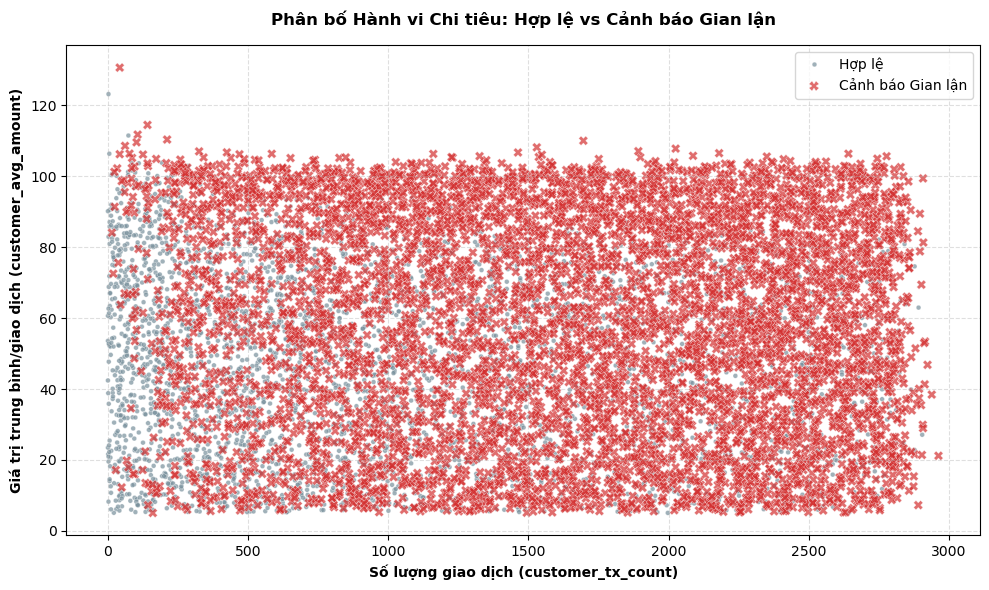

In [21]:
# Tạo nhãn Phân loại nhị phân
pdf_behavior['Loại khách hàng'] = pdf_behavior['total_fraud_count'].apply(
    lambda x: 'Hợp lệ' if x == 0 else 'Cảnh báo Gian lận'
)
pdf_behavior_sorted = pdf_behavior.sort_values(by="total_fraud_count", ascending=True)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pdf_behavior_sorted,
    x="customer_tx_count",
    y="customer_avg_amount",
    hue="Loại khách hàng",
    style="Loại khách hàng",
    palette={'Hợp lệ': '#78909c', 'Cảnh báo Gian lận': '#d32f2f'}, # Xám đốm vs Đỏ đậm
    size="Loại khách hàng",
    sizes={'Hợp lệ': 12, 'Cảnh báo Gian lận': 45}, # Điểm gian lận to gấp 4 lần
    alpha=0.7,
    linewidth=0.3,
    edgecolor='white'
)

plt.title("Phân bố Hành vi Chi tiêu: Hợp lệ vs Cảnh báo Gian lận", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Số lượng giao dịch (customer_tx_count)", fontsize=10, fontweight="bold")
plt.ylabel("Giá trị trung bình/giao dịch (customer_avg_amount)", fontsize=10, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


Phân tích Đột biến Ban đêm & Trạm POS

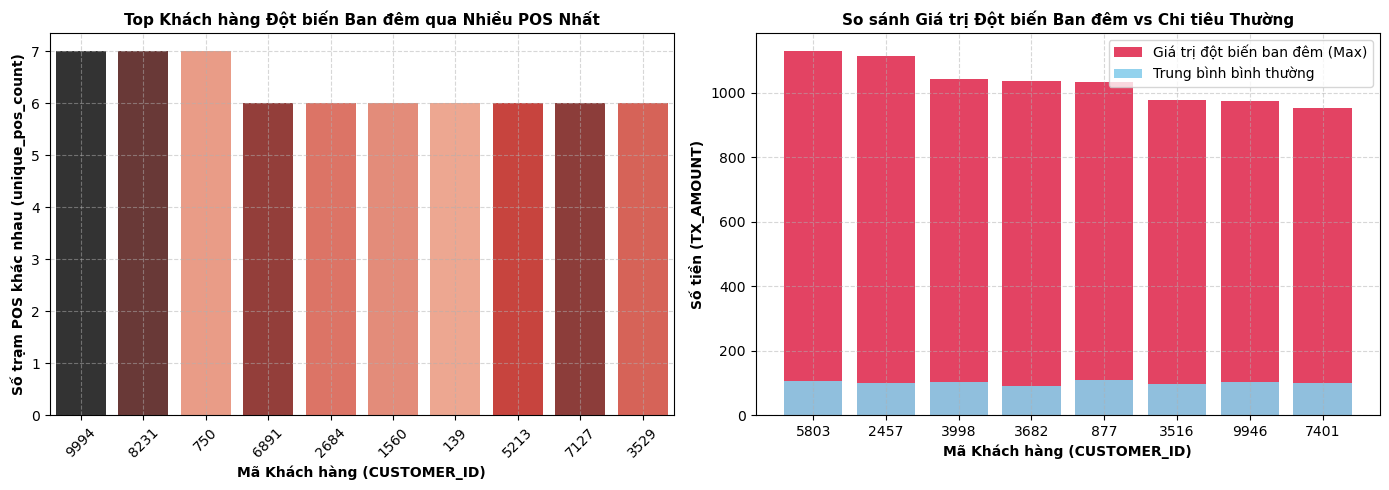

In [19]:
# 2. Khởi tạo khung vẽ 2 biểu đồ phân tích gian lận ban đêm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ A: Top khách hàng có giao dịch đột biến ban đêm qua nhiều trạm POS nhất
top_pos_spickers = pdf_night_spikes.sort_values(by="unique_pos_count", ascending=False).head(10)

sns.barplot(
    ax=axes[0],
    data=top_pos_spickers,
    x="CUSTOMER_ID",
    y="unique_pos_count",
    hue="CUSTOMER_ID",
    palette="Reds_d",
    legend=False,
    order=top_pos_spickers["CUSTOMER_ID"]
)
axes[0].set_title("Top Khách hàng Đột biến Ban đêm qua Nhiều POS Nhất", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Mã Khách hàng (CUSTOMER_ID)", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Số trạm POS khác nhau (unique_pos_count)", fontsize=10, fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Biểu đồ B: So sánh Giá trị Đột biến Ban đêm vs Mức trung bình bình thường
top_amount_spickers = pdf_night_spikes.sort_values(by="max_spike_amount", ascending=False).head(8)
x_labels = [str(cid) for cid in top_amount_spickers["CUSTOMER_ID"]]

axes[1].bar(x_labels, top_amount_spickers["max_spike_amount"], label="Giá trị đột biến ban đêm (Max)", color="crimson", alpha=0.8)
axes[1].bar(x_labels, top_amount_spickers["normal_avg_amount"], label="Trung bình bình thường", color="skyblue", alpha=0.9)
axes[1].set_title("So sánh Giá trị Đột biến Ban đêm vs Chi tiêu Thường", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Mã Khách hàng (CUSTOMER_ID)", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Số tiền (TX_AMOUNT)", fontsize=10, fontweight="bold")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
